
Processing sample: SSN138
Processing AMR_field_197.174deg_I_in_3.000mAtrace1.txt


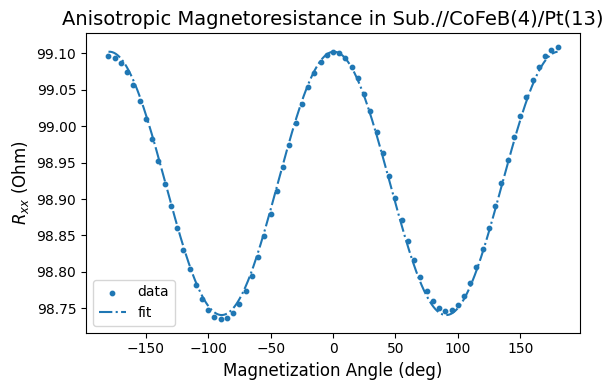

Processing AMR_field_197.497deg_I_in_6.000mAtrace1.txt


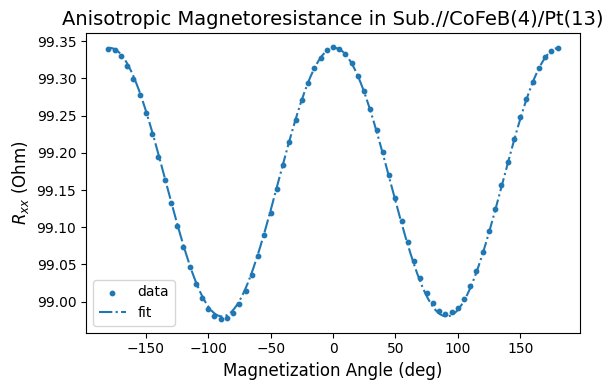

Processing AMR_field_197.574deg_I_in_9.000mAtrace1.txt


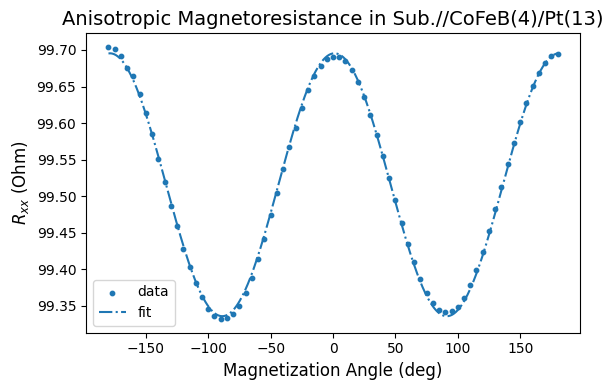


Processing sample: SSN139
Processing AMR_field_197.118deg_I_in_6.000mAtrace1.txt


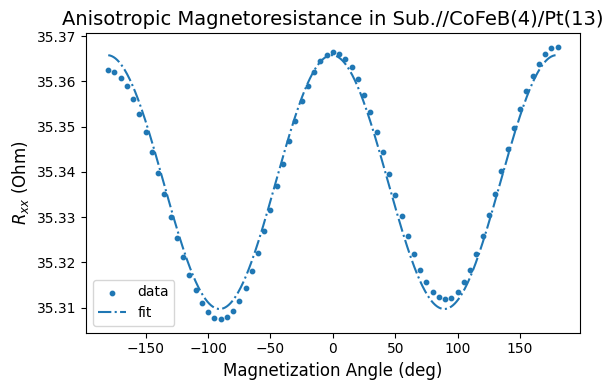

Processing AMR_field_197.155deg_I_in_3.000mAtrace1.txt


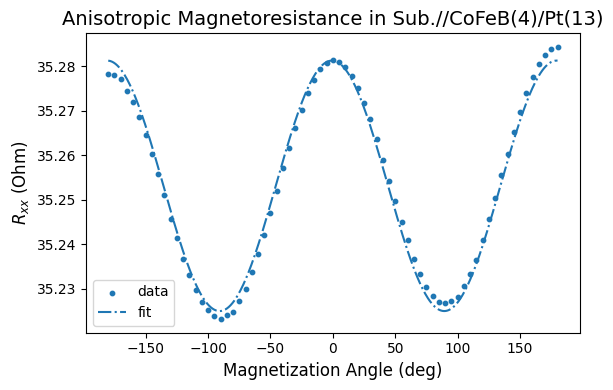

Processing AMR_field_197.465deg_I_in_9.000mAtrace1.txt


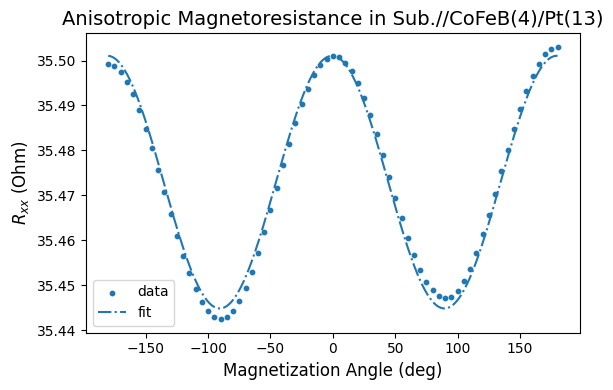


Processing sample: SSN140
Processing AMR_field_197.485deg_I_in_9.000mAtrace1.txt


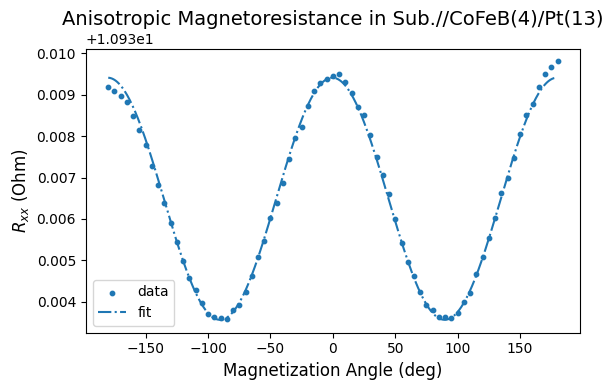


Processing sample: SSN141
Processing AMR_field_197.310deg_I_in_6.000mAtrace1.txt


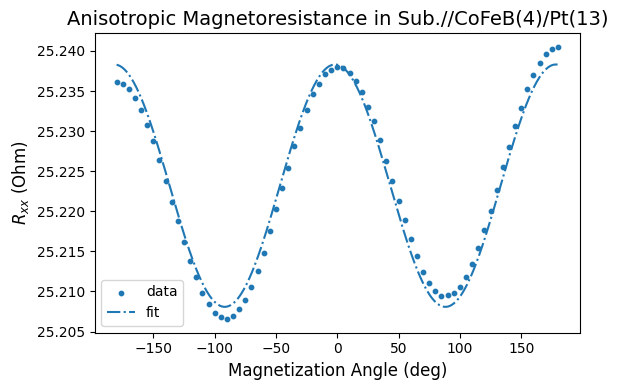

Processing AMR_field_197.626deg_I_in_9.000mAtrace1.txt


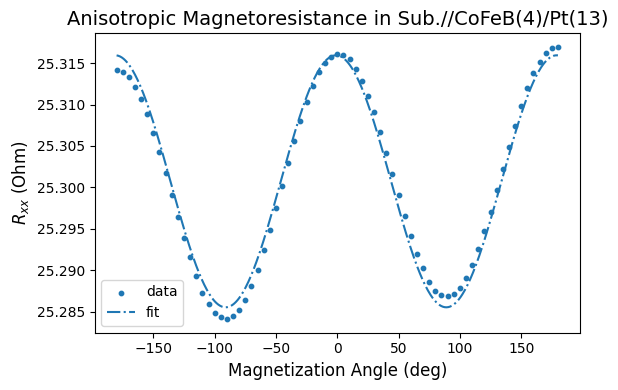


Processing sample: SSN143
Processing AMR_field_197.187deg_I_in_3.000mAtrace1.txt


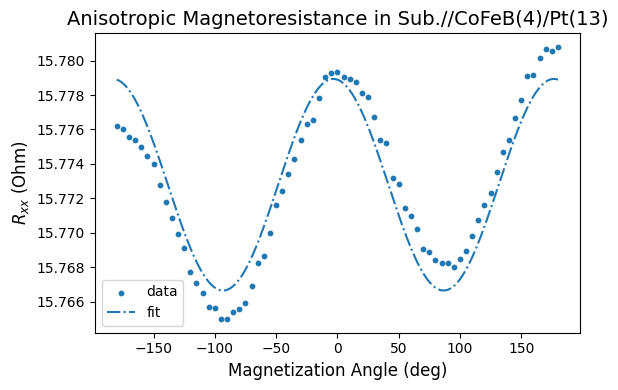

Processing AMR_field_197.568deg_I_in_6.000mAtrace1.txt


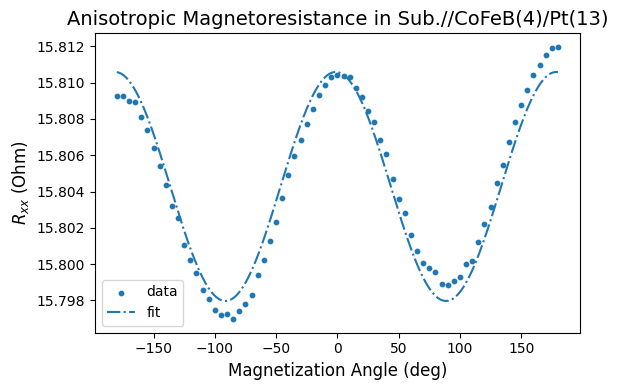

Processing AMR_field_197.568deg_I_in_9.000mAtrace1.txt


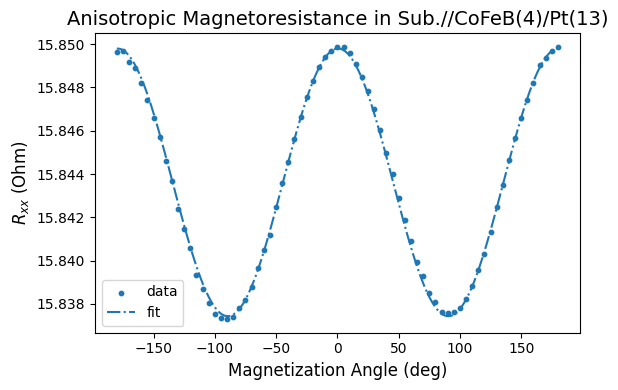


Analysis finished. Results saved to AMR_fit_summary.csv


In [4]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plot=True

def amr_model(phi, R0, dR, phi0):
    return R0 + dR * np.cos(phi - phi0)**2

# Root directory containing sample folders
root_dir = "."

# Regex to extract field and current from filename
pattern = re.compile(
    r"AMR_field_(?P<field>[0-9.]+)deg_I_in_(?P<current>[0-9.]+)mAtrace(?P<trace>[0-9]+)"
)

all_results = []

for sample in os.listdir(root_dir):

    sample_path = os.path.join(root_dir, sample)

    if not os.path.isdir(sample_path):
        continue

    print(f"\nProcessing sample: {sample}")

    for file in os.listdir(sample_path):

        match = pattern.match(file)
        if not match:
            continue

        field = float(match.group("field"))
        current = float(match.group("current"))
        trace = int(match.group("trace"))

        filepath = os.path.join(sample_path, file)

        try:

            # Read data (skip "R=100")
            df = pd.read_csv(filepath, sep="\t", skiprows=1)
            df.columns = [c.strip() for c in df.columns]

            angle_deg = df["Angle"].values
            phi = np.deg2rad(angle_deg) #+ np.pi/2
            angle_deg = np.rad2deg(phi)
            Rxx = df["Rxx (ohm)"].values

            # Initial guesses
            guess_R0 = np.mean(Rxx)
            guess_dR = (np.max(Rxx) - np.min(Rxx)) / 2
            guess_phi0 = 0

            # Fit
            popt, pcov = curve_fit(
                amr_model,
                phi,
                Rxx,
                p0=[guess_R0, guess_dR, guess_phi0],
                bounds=([-np.inf, 0, -np.pi/2], [np.inf, np.inf, np.pi/2])
            )

            R0_fit, dR_fit, phi0_fit = popt

            amr_ratio = dR_fit / R0_fit

            # errors
            perr = np.sqrt(np.diag(pcov))

            R0_err = perr[0]
            dR_err = perr[1]
            phi0_err = perr[2]
            amr_ratio_err = np.sqrt(
                (dR_err / R0_fit)**2 +
                (dR_fit * R0_err / R0_fit**2)**2
            )

            # Store results
            all_results.append({
                "sample": sample,
                "file": file,
                "field_mT": field,
                "current_mA": current,
                "trace": trace,

                "R0_ohm": R0_fit,
                "R0_err": R0_err,

                "deltaR_ohm": dR_fit,
                "deltaR_err": dR_err,

                "phi0_rad": phi0_fit,
                "phi0_rad_err": phi0_err,

                "phi0_deg": np.rad2deg(phi0_fit),
                "phi0_deg_err": np.rad2deg(phi0_err),

                "AMR_ratio": amr_ratio,
                "AMR_ratio_err": amr_ratio_err
            })

            # Plot data + fit
            phi_fit = np.linspace(min(phi), max(phi), 500)
            if plot:
                print(f"Processing {file}", flush=True)
                
                plt.figure(figsize=(6, 4))
                plt.scatter(angle_deg, Rxx, s=10, label="data")
                plt.plot(
                    np.rad2deg(phi_fit),
                    amr_model(phi_fit, *popt),
                    label="fit",
                    linestyle='-.'
                )
                plt.xlabel("Magnetization Angle (deg)", fontsize=12)
                plt.ylabel("$R_{xx}$ (Ohm)", fontsize=12)
                plt.title(f"Anisotropic Magnetoresistance in Sub.//CoFeB(4)/Pt(13)", fontsize=14)
                plt.legend()
                plt.tight_layout()
                plt.show(block=False)
                plt.pause(0.001)

        except Exception as e:
            print(f"Error processing {filepath}: {e}")


# Convert results to DataFrame
results_df = pd.DataFrame(all_results)
# print(results_df["current_mA"], results_df["R0_ohm"], results_df["deltaR_ohm"], results_df["phi0_deg"])

# Save summary file
results_df.to_csv("AMR_fit_summary.csv", index=False)

print("\nAnalysis finished. Results saved to AMR_fit_summary.csv")

In [2]:
import numpy as np

def weighted_mean_with_scatter(values, errors):

    values = np.array(values)
    errors = np.array(errors)

    weights = 1 / errors**2

    weighted_mean = np.sum(weights * values) / np.sum(weights)

    weighted_err = np.sqrt(1 / np.sum(weights))

    scatter = np.std(values, ddof=1)

    total_err = np.sqrt(weighted_err**2 + scatter**2)

    return weighted_mean, total_err, scatter


summary_rows = []

for sample in results_df["sample"].unique():

    df_sample = results_df[results_df["sample"] == sample]

    # R0
    R0_mean, R0_err, R0_scatter = weighted_mean_with_scatter(
        df_sample["R0_ohm"],
        df_sample["R0_err"]
    )

    # dR
    dR_mean, dR_err, dR_scatter = weighted_mean_with_scatter(
        df_sample["deltaR_ohm"],
        df_sample["deltaR_err"]
    )

    summary_rows.append({
        "sample": sample,

        "R0_mean": R0_mean,
        "R0_err": R0_err,
        "R0_scatter": R0_scatter,

        "dR_mean": dR_mean,
        "dR_err": dR_err,
        "dR_scatter": dR_scatter
    })

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv("AMR_sample_summary.csv", index=False)

print(summary_df)

   sample    R0_mean    R0_err  R0_scatter   dR_mean    dR_err  dR_scatter
0  SSN138  99.048026  0.299396    0.299396  0.360601  0.001228    0.000999
1  SSN139  35.327159  0.110876    0.110875  0.056252  0.000386    0.000129
2  SSN140  10.933566       NaN         NaN  0.005844       NaN         NaN
3  SSN141  25.252484  0.054773    0.054773  0.030325  0.000320    0.000113
4  SSN143  15.835473  0.035468    0.035468  0.012371  0.000182    0.000175


c:\git\MasterProject\venv\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\git\MasterProject\venv\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


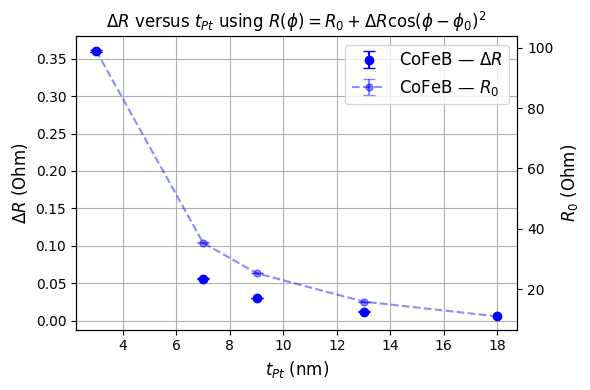

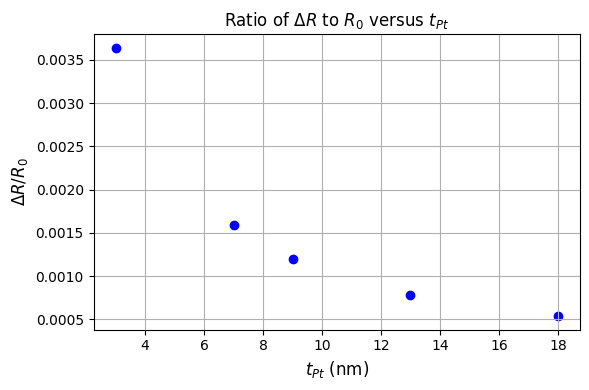

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

thickness_map = {
    "SSN138": {"t_FM": 4e-9,"t_NM": 3e-9,"label": "CoFeB"},
    "SSN101": {"t_FM": 4e-9,"t_NM": 5e-9,"label": "CoFeB"},
    "SSN139": {"t_FM": 4e-9,"t_NM": 7e-9,"label": "CoFeB"},
    "SSN140": {"t_FM": 4e-9,"t_NM": 18e-9,"label": "CoFeB"},
    "SSN141": {"t_FM": 4e-9,"t_NM": 9e-9,"label": "CoFeB"},
    "SSN142": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CoFeB"},
    "SSN095": {"t_FM": 4e-9,"t_NM": 15e-9,"label": "CoFeB"},
    "SSN143": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CoFeB"},
    "AD016": {"t_FM": 5e-9,"t_NM": 3e-9,"label": "Permalloy"},
    "AD017": {"t_FM": 5e-9,"t_NM": 5e-9,"label": "Permalloy"},
    # "AD018": {"t_FM": 5e-9,"t_NM": 7e-9,"label": "Permalloy"},
    "AD019": {"t_FM": 5e-9,"t_NM": 9e-9,"label": "Permalloy"},
    "AD020": {"t_FM": 5e-9,"t_NM": 13e-9,"label": "Permalloy"},
    "AD021": {"t_FM": 5e-9,"t_NM": 18e-9,"label": "Permalloy"},
}

# Map thickness and label from thickness_map
summary_df["t_NM"]    = summary_df["sample"].map(lambda x: thickness_map[x]["t_NM"])
summary_df["t_NM_nm"] = summary_df["t_NM"] * 1e9
summary_df["label"]   = summary_df["sample"].map(lambda x: thickness_map[x]["label"])
summary_df = summary_df.sort_values("t_NM_nm")

# --- Style maps: one entry per unique label ---
color_map  = {label: c for label, c in zip(
    summary_df["label"].unique(),
    ["blue", "red", "green", "orange", "purple", "brown"]
)}
marker_map = {label: m for label, m in zip(
    summary_df["label"].unique(),
    ["o", "s", "^", "D", "v", "P"]
)}

# ── Plot 1: dR (left) and R0 (right) ─────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

for label, group in summary_df.groupby("label"):
    color  = color_map[label]
    marker = marker_map[label]

    # Left axis: dR
    ax1.errorbar(
        group["t_NM_nm"], group["dR_mean"], yerr=group["dR_err"],
        fmt=marker, capsize=4, color=color,
        label=f"{label} — $\\Delta R$",
    )
    # Right axis: R0 (lighter shade via alpha, smaller marker)
    ax2.errorbar(
        group["t_NM_nm"], group["R0_mean"], yerr=group["R0_err"],
        fmt=marker, capsize=4, color=color, alpha=0.45,
        markersize=5, linestyle="--",
        label=f"{label} — $R_0$",
    )

ax1.set_xlabel("$t_{Pt}$ (nm)", fontsize=12)
ax1.set_ylabel("$\\Delta R$ (Ohm)", fontsize=12)
ax2.set_ylabel("$R_0$ (Ohm)", fontsize=12)
ax1.grid(True)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=12)

plt.title(
    "$\\Delta R$ versus $t_{Pt}$ using "
    "$R(\\phi) = R_0 + \\Delta R\\cos(\\phi - \\phi_0)^2$"
)
plt.tight_layout()
plt.show()

# ── Plot 2: dR / R0 ratio ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

for label, group in summary_df.groupby("label"):
    ax.scatter(
        group["t_NM_nm"],
        group["dR_mean"] / group["R0_mean"],
        marker=marker_map[label],
        color=color_map[label],
        # linestyle="-",
        label=label,
    )

ax.set_xlabel("$t_{Pt}$ (nm)", fontsize=12)
ax.set_ylabel("$\\Delta R / R_0$", fontsize=12)
ax.set_title("Ratio of $\\Delta R$ to $R_0$ versus $t_{Pt}$")
# ax.legend(fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.show()

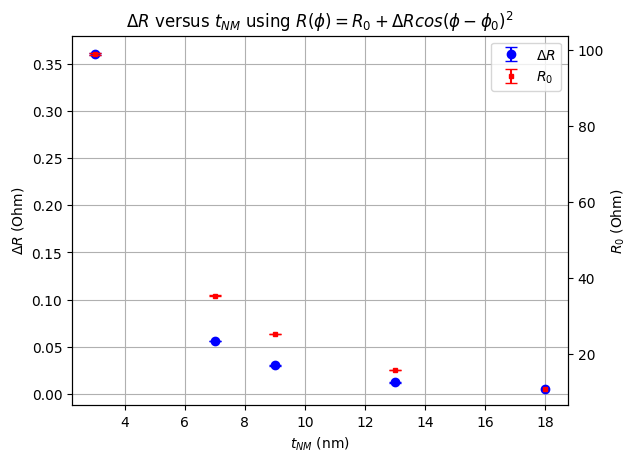

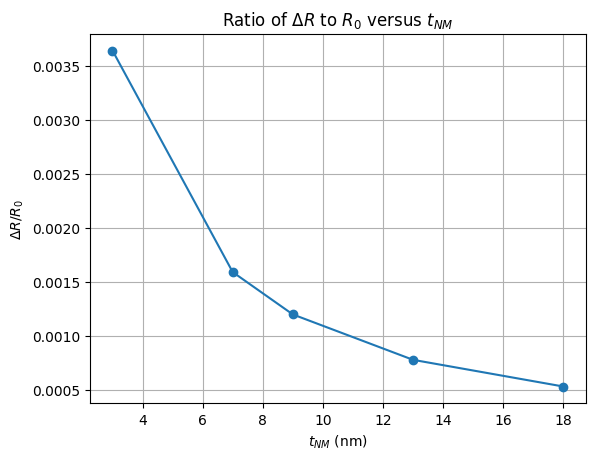

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

thickness_map = {
    "SSN138": {"t_FM": 4e-9,"t_NM": 3e-9,"label": "CoFeB"},
    "SSN101": {"t_FM": 4e-9,"t_NM": 5e-9,"label": "CoFeB"},
    "SSN139": {"t_FM": 4e-9,"t_NM": 7e-9,"label": "CoFeB"},
    "SSN140": {"t_FM": 4e-9,"t_NM": 18e-9,"label": "CoFeB"},
    "SSN141": {"t_FM": 4e-9,"t_NM": 9e-9,"label": "CoFeB"},
    "SSN142": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CoFeB"},
    "SSN095": {"t_FM": 4e-9,"t_NM": 15e-9,"label": "CoFeB"},
    "SSN143": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CoFeB"},
    "AD017": {"t_FM": 5e-9,"t_NM": 5e-9,"label": "Permalloy"},
    "AD018": {"t_FM": 5e-9,"t_NM": 7e-9,"label": "Permalloy"},
    "AD019": {"t_FM": 5e-9,"t_NM": 9e-9,"label": "Permalloy"},
    "AD020": {"t_FM": 5e-9,"t_NM": 13e-9,"label": "Permalloy"},
    "AD021": {"t_FM": 5e-9,"t_NM": 18e-9,"label": "Permalloy"},

}
# assuming your dataframe is called df
summary_df["t_NM"] = summary_df["sample"].map(lambda x: thickness_map[x]["t_NM"])
summary_df["t_NM_nm"] = summary_df["t_NM"] * 1e9
summary_df = summary_df.sort_values("t_NM_nm")


import matplotlib.pyplot as plt

# sort for nicer plotting
summary_df = summary_df.sort_values("t_NM_nm")

fig, ax1 = plt.subplots()

# --- Left axis: dR ---
ax1.errorbar(
    summary_df["t_NM_nm"],
    summary_df["dR_mean"],
    yerr=summary_df["dR_err"],
    fmt='o',
    capsize=4,
    label="$\\Delta R$",
    color='blue'
)
ax1.set_xlabel("$t_{NM}$ (nm)")
ax1.set_ylabel("$\\Delta R$ (Ohm)")
ax1.grid(True)

# --- Right axis: R0 ---
ax2 = ax1.twinx()

ax2.errorbar(
    summary_df["t_NM_nm"],
    summary_df["R0_mean"],
    yerr=summary_df["R0_err"],
    fmt='s',
    capsize=4,
    # linestyle='--',
    label="$R_0$",
    color='red',
    markersize=3
)
ax2.set_ylabel("$R_0$ (Ohm)")

# --- Optional: combine legends ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

# plt.xlabel("$t_{NM}$ (nm)")
# plt.ylabel("$\\Delta R$")
plt.title("$\\Delta R$ versus $t_{NM}$ using $R(\\phi) = R_0 + \\Delta R cos(\\phi - \\phi_0)^2$")

# plt.grid(True)
plt.show()

plt.plot(summary_df["t_NM_nm"], summary_df["dR_mean"]/summary_df["R0_mean"], 'o-')
plt.xlabel("$t_{NM}$ (nm)")
plt.ylabel("$\\Delta R / R_0$")
plt.title("Ratio of $\\Delta R$ to $R_0$ versus $t_{NM}$")
plt.grid(True)
plt.show()


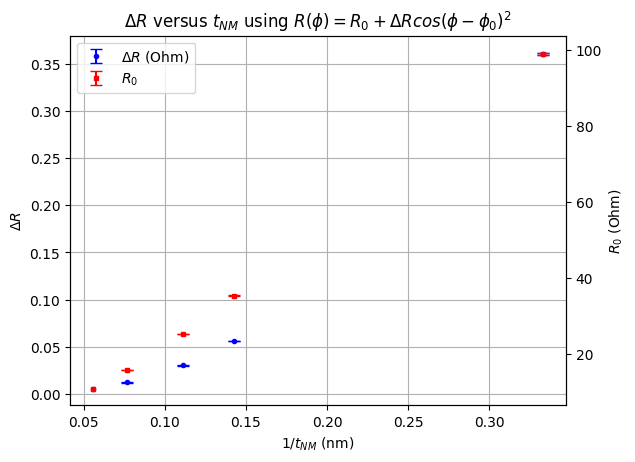

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

thickness_map = {
    "SSN138": {"t_FM": 4e-9,"t_NM": 3e-9,"label": "CFB4"},
    "SSN101": {"t_FM": 4e-9,"t_NM": 5e-9,"label": "CFB4"},
    "SSN139": {"t_FM": 4e-9,"t_NM": 7e-9,"label": "CFB4"},
    "SSN140": {"t_FM": 4e-9,"t_NM": 18e-9,"label": "CFB4"},
    "SSN141": {"t_FM": 4e-9,"t_NM": 9e-9,"label": "CFB4"},
    "SSN142": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CFB4"},
    "SSN095": {"t_FM": 4e-9,"t_NM": 15e-9,"label": "CFB4"},
    "SSN143": {"t_FM": 4e-9,"t_NM": 13e-9,"label": "CFB4"},
}
# assuming your dataframe is called df
summary_df["t_NM"] = summary_df["sample"].map(lambda x: thickness_map[x]["t_NM"])
summary_df["t_NM_nm"] = summary_df["t_NM"] * 1e9
summary_df = summary_df.sort_values("t_NM_nm")


import matplotlib.pyplot as plt

# sort for nicer plotting
summary_df = summary_df.sort_values("t_NM_nm")

fig, ax1 = plt.subplots()

# --- Left axis: dR ---
ax1.errorbar(
    1/summary_df["t_NM_nm"],
    summary_df["dR_mean"],
    yerr=summary_df["dR_err"],
    fmt='o',
    capsize=4,
    label="$\\Delta R$ (Ohm)",
    color='blue',
    markersize=3

)
ax1.set_xlabel("1/$t_{NM}$ (nm)")
ax1.set_ylabel("$\\Delta R$")
ax1.grid(True)

# --- Right axis: R0 ---
ax2 = ax1.twinx()

ax2.errorbar(
    1/summary_df["t_NM_nm"],
    summary_df["R0_mean"],
    yerr=summary_df["R0_err"],
    fmt='s',
    capsize=4,
    # linestyle='--',
    label="$R_0$",
    color='red',
    markersize=3
)
ax2.set_ylabel("$R_0$ (Ohm)")

# --- Optional: combine legends ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

# plt.xlabel("$t_{NM}$ (nm)")
# plt.ylabel("$\\Delta R$")
plt.title("$\\Delta R$ versus $t_{NM}$ using $R(\\phi) = R_0 + \\Delta R cos(\\phi - \\phi_0)^2$")

# plt.grid(True)
plt.show()

